# Acquisition notebook

This notebook is split between:
- **run cells** here
- reusable helpers in the `utils/` Python files next to the notebook

The goal is to keep this notebook readable and focused on experiments.

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import serial
import serial.tools.list_ports
import pyvisa as pv

In [4]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from datetime import datetime
from pathlib import Path

In [5]:
from utils.oc3 import OC3
from utils.pm100a import record_pm100a
from utils.naming import make_run_dir

from utils.temperature import generate_temperature_list

In [6]:
DATA_DIR = "data/data_temp_SHG"
os.makedirs(DATA_DIR, exist_ok=True)

In [7]:
wavelength = 390e-6 # wavelength in microns!

In [8]:
# Check available VISA resources
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x0699::0x039F::C010359::INSTR', 'USB0::0x1313::0x8078::P0025589::INSTR', 'USB0::0x1313::0x8079::P1007388::INSTR', 'ASRL1::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR')


In [8]:
# Connnect to Tektronix oscilloscope
# tektronik = rm.open_resource('USB0::0x0699::0x039F::C010359::INSTR')
# print(tektronik.query("*IDN?"))

In [9]:
# Connect to PM100A power meter via PyVISA
# you can use the tool Power Meter Driver Switcher to switch between the two drivers, the PM100D.dll driver and the new TLPM.dll driver. 
# Pyvisa may not recognize the PM100A with the WinUSB driver, so you may need to switch to the Visa driver. 
pm100a = rm.open_resource('USB0::0x1313::0x8079::P1007388::INSTR')
# pm100d = rm.open_resource('USB0::0x1313::0x8078::P0008159::INSTR')  # PESTO powermeter for input power measurement
pm100d = rm.open_resource('USB0::0x1313::0x8078::P0025589::INSTR')   # Musiqs powermeter for input power measurement
print(pm100a.query('*IDN?'))
print(pm100d.query('*IDN?'))

Thorlabs,PM100A,P1007388,2.5.0

Thorlabs,PM100D,P0025589,2.8.1



## Temperature sweep with PM100A or Tektronik + OC3

This run:
- connects the PM100A or Tektronik for power reading
- uses the OC3 for temperature control
- waits for stabilization
- optionally asks for manual lock confirmation
- reads one or several PM100A values per temperature
- saves one CSV per temperature and one summary CSV

In [18]:
RUN_DIR = r"data/data_temp_SHG/SHG_temp_input_power_scan/2026-06-15_ppktp_svenska_20_jesse_003/SHG_temp_input_power_scan_ppktp_svenska_20_jesse"
ACQ_CELL = "SHG_temp_input_power_scan_ppktp_svenska_20_jesse"

In [10]:
# FOLDER
# SAMPLE = "ppktp_svenska_10"
# SAMPLE = "ppktp_svenska_20_jesse"
SAMPLE = "ppktp_svenska_20_luke"
MEAS = "SHG_temp_input_power_scan"
ACQ_CELL = f"{MEAS}_{SAMPLE}"

RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)

print("Temperature scan data will be saved in:", RUN_DIR)

Saving data to: data/data_temp_SHG\SHG_temp_input_power_scan\2026-06-18_ppktp_svenska_20_luke_001
Temperature scan data will be saved in: data/data_temp_SHG\SHG_temp_input_power_scan\2026-06-18_ppktp_svenska_20_luke_001


In [11]:
print("ID:", pm100a.query("*IDN?"))
print("Wavelength:", pm100a.query("SENS:CORR:WAV?"))
print("Power READ?:", pm100a.query("READ?"))
print("Power MEAS?:", pm100a.query("MEAS:POW?"))
print("Unit:", pm100a.query("SENS:POW:UNIT?"))
print("Range auto:", pm100a.query("SENS:POW:RANG:AUTO?"))
print("Range:", pm100a.query("SENS:POW:RANG?"))

ID: Thorlabs,PM100A,P1007388,2.5.0

Wavelength: 3.900000E+02

Power READ?: 2.00863742E-05

Power MEAS?: 6.74594776E-05

Unit: W

Range auto: 0

Range: 2.650394E-01



In [11]:
plist = list(serial.tools.list_ports.comports())
print(plist)

[<serial.tools.list_ports_common.ListPortInfo object at 0x0000019E729E3380>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000019E72C982D0>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000019E72C98410>]


In [12]:
# Connect to OC3 temperature controller via pyserial
# OC_PORT = "COM3" 
OC_PORT = "COM5"
oc3 = OC3(port=OC_PORT)
print("Connected to OC3 on port", OC_PORT, oc3.status())

Connected to OC3 on port COM5 b'j5542.000;41.998;1;04.0;0;0;1;23.973;c24/1.54p;0;0;42.000;68'


In [ ]:
ASK_USER_CONFIRMATION = False

# TEMPERATURE CONTROL
TEMP_START = 41.5
TEMP_END = 43.5
TEMP_STEP = 0.05
RAMP_RATE = 0.02

TEMP_TOL = 0.01
STABLE_TIME = 30.0
POLL_INTERVAL = 1.0

# POWER-METER
PM_SAMPLES_PER_POINT = 20
PM_SAMPLE_DELAY = 0.1

PM_RECORD_DURATION = 2          # seconds
PM_SAMPLE_DELAY = 0.1          # seconds between reads
PM_AVERAGE_COUNT = 1           # instrument-side averaging

In [14]:
temps = generate_temperature_list(TEMP_START, TEMP_END, TEMP_STEP)
print("Temperature list:", temps)
print(f"Total points: {len(temps)}")

Temperature list: [40.5, 40.55, 40.6, 40.65, 40.7, 40.75, 40.8, 40.85, 40.9, 40.95, 41.0, 41.05, 41.1, 41.15, 41.2, 41.25, 41.3, 41.35, 41.4, 41.45, 41.5, 41.55, 41.6, 41.65, 41.7, 41.75, 41.8, 41.85, 41.9, 41.95, 42.0, 42.05, 42.1, 42.15, 42.2, 42.25, 42.3, 42.35, 42.4, 42.45, 42.5, 42.55, 42.6, 42.65, 42.7, 42.75, 42.8, 42.85, 42.9, 42.95, 43.0, 43.05, 43.1, 43.15, 43.2, 43.25, 43.3, 43.35, 43.4, 43.45, 43.5]
Total points: 61


In [17]:
# Input power measurement with PM100D
pump_power_mW, error_in_mW, values_mW = record_pm100a(
        pm100d,
        duration_s=5,
        dt_s=PM_SAMPLE_DELAY
    )
print(f"Mean input power = {pump_power_mW:.6f} ± {error_in_mW:.6f} mW")

Mean input power = 199.382007 ± 0.023263 mW


INFO:1:2026_06_18__09_57_28__SHG_temp_input_power_scan_ppktp_svenska_20_luke



Point 1/61  |  Set temperature = 40.500 °C
Current T: 40.515  ± 0.000 °C
Mean power = 4.502273 ± 0.011773 mW
Input power = 199.382007 ± 0.023263 mW

Point 2/61  |  Set temperature = 40.550 °C
Current T: 40.559  ± 0.000 °C
Mean power = 3.690229 ± 0.010672 mW
Input power = 199.382007 ± 0.023263 mW

Point 3/61  |  Set temperature = 40.600 °C
Current T: 40.605  ± 0.001 °C
Mean power = 3.064340 ± 0.005987 mW
Input power = 199.382007 ± 0.023263 mW

Point 4/61  |  Set temperature = 40.650 °C
Current T: 40.660  ± 0.001 °C
Mean power = 2.873629 ± 0.006723 mW
Input power = 199.382007 ± 0.023263 mW

Point 5/61  |  Set temperature = 40.700 °C
Current T: 40.706  ± 0.001 °C
Mean power = 3.330366 ± 0.006230 mW
Input power = 199.382007 ± 0.023263 mW

Point 6/61  |  Set temperature = 40.750 °C
Current T: 40.759  ± 0.001 °C
Mean power = 4.328567 ± 0.014296 mW
Input power = 199.382007 ± 0.023263 mW

Point 7/61  |  Set temperature = 40.800 °C
Current T: 40.808  ± 0.001 °C
Mean power = 5.376572 ± 0.011179

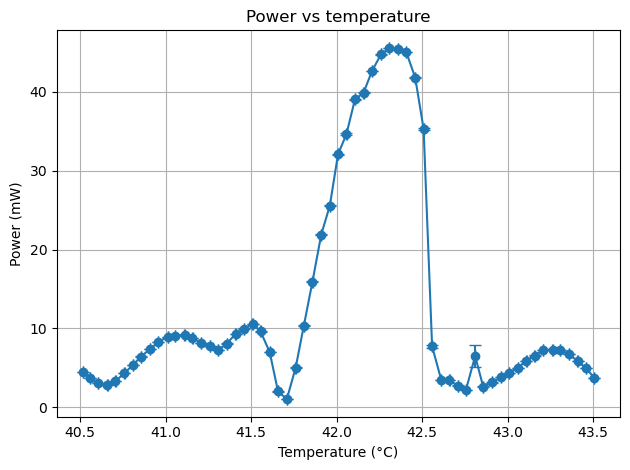

In [18]:
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)


PM_RECORD_DURATION = 5      # seconds
oc3.enable()

scan_results = []
list_SHG_powers , list_SHG_errors = [] , []
list_Tmeas , list_Terrors = [] , []
for i, T in enumerate(temps, start=1):
    print("\n" + "=" * 60)
    print(f"Point {i}/{len(temps)}  |  Set temperature = {T:.3f} °C")
    print("=" * 60)

    oc3.set_temperature(T, ramp=RAMP_RATE)
    time.sleep(10)  # wait for the temperature to start ramping

    Tmeas, Terror = oc3.get_mean_temperature(duration_s=4.0)
    print(f"Current T: {Tmeas:.3f}  ± {Terror:.3f} °C")

    mean_mW, error_mW, values_mW = record_pm100a(
        pm100a,
        duration_s=4,
        dt_s=PM_SAMPLE_DELAY
    )
    list_SHG_powers.append(mean_mW)
    list_SHG_errors.append(error_mW)
    list_Tmeas.append(Tmeas)
    list_Terrors.append(Terror)
    print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")
    print(f"Input power = {pump_power_mW:.6f} ± {error_in_mW:.6f} mW")

oc3.set_temperature(temps[0], ramp=RAMP_RATE)
time.sleep(5)
plt.errorbar(list_Tmeas, list_SHG_powers, xerr = list_Terrors, yerr = list_SHG_errors , fmt="o-", capsize=4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Power (mW)")
plt.title("Power vs temperature")
plt.grid(True)
plt.tight_layout()
plt.show()


# aqm.save_acquisition(list_Tmeas=list_Tmeas, list_SHG_powers=list_SHG_powers, list_SHG_errors=list_SHG_errors, list_Terrors=list_Terrors , pump_power_mW = 300)
aqm.save_acquisition(list_Tmeas=list_Tmeas, list_SHG_powers=list_SHG_powers, list_SHG_errors=list_SHG_errors, list_Terrors=list_Terrors , pump_power_mW=pump_power_mW, error_in_mW=error_in_mW, values_mW=values_mW)

## Single pass test

We set the right temperature on the OC3, and test different waist values. We simply record the average over time on the power-meter.

In [9]:
# FOLDER
SAMPLE = "ppktp_20"
MEAS = "waist_scan_singlepass"
ACQ_CELL = f"{MEAS}_{SAMPLE}"

RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)

print("Temperature scan data will be saved in:", RUN_DIR)

Waist scan data will be saved in: data/data_temp_SHG\waist_scan 05 05


In [19]:
# Check OC3 status
Tmeas, Terror = oc3.get_mean_temperature(duration_s=4.0)
print(f"Current T: {Tmeas:.3f}  ± {Terror:.3f} °C")

Current T: 44.850  ± 0.001 °C


In [ ]:
# Get current power reading
raw = pm100a.query("READ?").strip()
print("Current power reading (raw):", raw)

# Set input power
Pin = 
focal_length_mm = 100.0
waist_um = 

# Set scan parameters
duration_s = 10

Current power reading (raw): 1.11528760E-04


In [ ]:
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)

mean_mW, error_mW = record_pm100a(
        pm100a,
        duration_s=duration_s,
        dt_s=0.1
    )

print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")

# Save acquisition data ()
aqm.save_acquisition(Pin=Pin, focal_length_mm=focal_length_mm, waist_um=waist_um, mean_mW=mean_mW, error_mW=error_mW, Tmeas=Tmeas, Terror=Terror)

INFO:1:2026_05_05__15_15_47__waist_scan


Mean power = 0.106894 ± 0.001476 mW
